In [1]:
from fastbook import *
from fastai.vision.widgets import *

In [2]:
def get_ridx(b):
    # r = random.randint(0, len(ims))
    r = random.randrange(b) if b > 0 else -1
    return r

[get_ridx(i) for i in (200, -1, 0)]

[163, -1, -1]

In [3]:
ISTEST = False

In [4]:
if ISTEST:
    # bear_types = ['non']
    bear_types = ['grizzly', 'binturong']
    bear_label = ['grizzly', 'non']
else:
    bear_types = ['grizzly', 'black', 'teddy', 'binturong']
    bear_label = ['grizzly', 'black', 'teddy', 'non']
path = Path('multi_bears')

In [5]:
if ISTEST:
    if path.exists():
        shutil.rmtree(path)
    max_images = 10
else:
    max_images = 200

if not path.exists():
    path.mkdir()
    for i, o in enumerate(bear_types):
        dest = (path/o) if not bear_label else (path/bear_label[i])
        dest.mkdir(exist_ok=True)
        results = search_images_ddg(f'{o} bear', max_images=max_images)
        download_images(dest, urls=results)

In [6]:
fns = get_image_files(path)
fns

(#703) [Path('multi_bears/non/d8df0ac9-500d-4403-b024-486761fd74ec.jpg'),Path('multi_bears/non/c7322db8-acb7-49e7-8634-111b2c287a29.jpg'),Path('multi_bears/non/ce305113-7b7e-4e97-b1f0-4189223199f0.jpg'),Path('multi_bears/non/7aa6f4c4-9f7f-4ac9-af11-f25031ab2e82.jpg'),Path('multi_bears/non/e8749b62-0b08-4fae-9459-80339bf1b68b.jpg'),Path('multi_bears/non/ba3f34d4-334c-4608-beec-c7148fce4554.jpg'),Path('multi_bears/non/2e8a503a-5f5c-4ec7-94ae-7c512704ed5a.jpg'),Path('multi_bears/non/74fd0462-3116-475f-a40e-ff824b3cccd5.jpg'),Path('multi_bears/non/218c2ceb-b527-4cb9-a44a-46907ead6637.jpg'),Path('multi_bears/non/0d42b622-f253-4a07-bcd4-eb2abe26f2c9.jpg')...]

In [7]:
failed = verify_images(fns)
failed

(#0) []

In [8]:
failed.map(Path.unlink)

(#0) []

In [9]:
fns = get_image_files(path)
fns

(#703) [Path('multi_bears/non/d8df0ac9-500d-4403-b024-486761fd74ec.jpg'),Path('multi_bears/non/c7322db8-acb7-49e7-8634-111b2c287a29.jpg'),Path('multi_bears/non/ce305113-7b7e-4e97-b1f0-4189223199f0.jpg'),Path('multi_bears/non/7aa6f4c4-9f7f-4ac9-af11-f25031ab2e82.jpg'),Path('multi_bears/non/e8749b62-0b08-4fae-9459-80339bf1b68b.jpg'),Path('multi_bears/non/ba3f34d4-334c-4608-beec-c7148fce4554.jpg'),Path('multi_bears/non/2e8a503a-5f5c-4ec7-94ae-7c512704ed5a.jpg'),Path('multi_bears/non/74fd0462-3116-475f-a40e-ff824b3cccd5.jpg'),Path('multi_bears/non/218c2ceb-b527-4cb9-a44a-46907ead6637.jpg'),Path('multi_bears/non/0d42b622-f253-4a07-bcd4-eb2abe26f2c9.jpg')...]

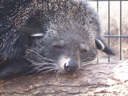

In [10]:
ridx = get_ridx(len(fns))
dest = fns[ridx]
im = Image.open(dest)
im.to_thumb(128,128)

In [11]:
def get_y(r): return [parent_label(r)]

In [12]:
bears = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    # blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    # get_y=parent_label,
    get_y=get_y,
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms(),
)
dsets = bears.datasets(path)
dls = bears.dataloaders(path)

In [13]:
dsets.train[0]

(PILImage mode=RGB size=800x535, TensorMultiCategory([0., 1., 0., 0.]))

/home/hao/miniconda3/envs/fastai/lib/python3.10/site-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


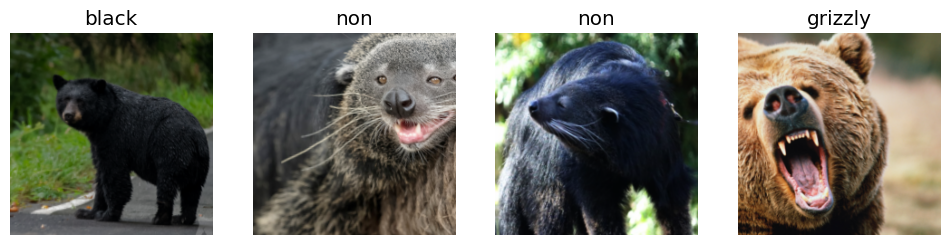

In [14]:
dls.show_batch(nrows=1, ncols=4, unique=False)

In [15]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

In [16]:
learn = vision_learner(
    dls,
    resnet50,
    metrics=partial(accuracy_multi, thresh=0.5),
)

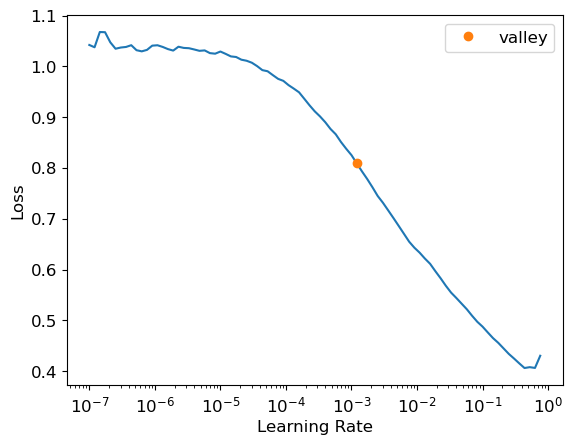

In [17]:
lr_ret = learn.lr_find()

In [18]:
lr_ret, lr_ret.valley

(SuggestedLRs(valley=0.0012022644514217973), 0.0012022644514217973)

In [19]:
learn.fine_tune(3, base_lr=lr_ret.valley, freeze_epochs=40)

epoch,train_loss,valid_loss,accuracy_multi,time


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.039022,0.058652,0.980357,00:13
1,0.030915,0.057854,0.982143,00:13
2,0.030991,0.057585,0.982143,00:13


In [20]:
preds,targs = learn.get_preds()

(tensor(17),
 tensor(0.5964),
 17,
 0.5964285731315613,
 0.5964285731315613,
 0.9839285612106323)

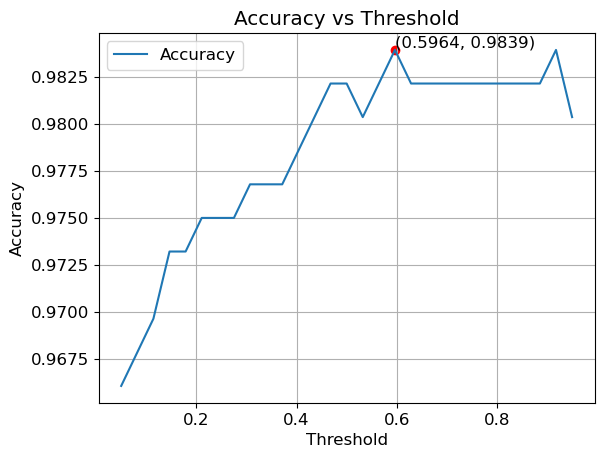

In [21]:
xs = torch.linspace(0.05,0.95,29)
accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs,accs, label='Accuracy')

max_idx = torch.argmax(torch.tensor(accs))
max_x = xs[max_idx].item()
max_y = accs[max_idx].item()
plt.scatter(max_x, max_y, color='red')

plt.text(max_x, max_y, f'({max_x:.4f}, {max_y:.4f})', fontsize=12, verticalalignment='bottom')
plt.title('Accuracy vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

max_idx, xs[max_idx], max_idx.item(), xs[max_idx].item(), max_x, max_y